In [4]:
print('jai jagganath')

jai jagganath


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [6]:
df=pd.read_csv('/content/customer_shopping_behavior.csv')

In [7]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [9]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [10]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [11]:
df['Review Rating']=df.groupby('Category')['Review Rating'].transform(lambda x:x.fillna(x.median()))

In [12]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [13]:
#changing column names to improve readability
df.columns=df.columns.str.lower()
df.columns=df.columns.str.replace(' ','_')


In [14]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [15]:
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [16]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [17]:
# create a column age_group
labels=['Young Adult','Adult','Middle-aged','Senior']
df['age_group']=pd.qcut(df['age'], q=4, labels=labels)

In [18]:
df[['age_group','age']]

,age_group,age
0,Middle-aged,55
1,Young Adult,19
2,Middle-aged,50
3,Young Adult,21
4,Middle-aged,45
...,...,...
3895,Adult,40
3896,Middle-aged,52
3897,Middle-aged,46
3898,Adult,44


In [19]:
# create a column purchase_frequency_days
frequency_mapping={
    'Fortnightly':14,
    'Weekly':7,
    'Monthly':30,
    'Quarterly':90,
    'Bi-Weekly':14,
    'Annually':365,
    'Every 3 Months':90
}
df['purchase_frequency_days']=df['frequency_of_purchases'].map(frequency_mapping)


In [20]:
df[['purchase_frequency_days','frequency_of_purchases']]

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
...,...,...
3895,7,Weekly
3896,14,Bi-Weekly
3897,90,Quarterly
3898,7,Weekly


In [21]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [22]:
(df['discount_applied']==df['promo_code_used']).all()

np.True_

In [23]:
df=df.drop('promo_code_used', axis=1)

In [24]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

In [25]:
df.to_csv("customer_behavior_cleaned.csv", index=False)

In [26]:
from google.colab import files
files.download("customer_behavior_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

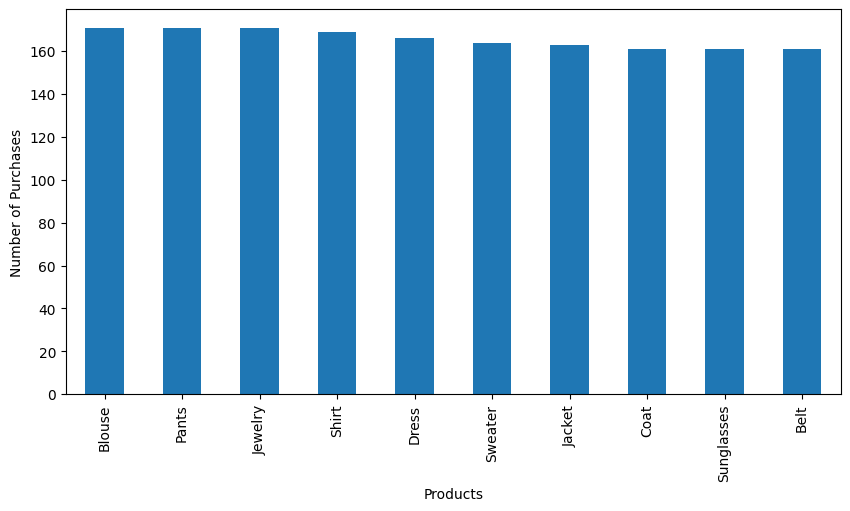

In [30]:
# Top 10 Most Purchased Products
top_product=df['item_purchased'].value_counts().head(10)
plt.figure(figsize=(10,5))
top_product.plot(kind='bar')
plt.xlabel('Products')
plt.ylabel('Number of Purchases')
plt.show()


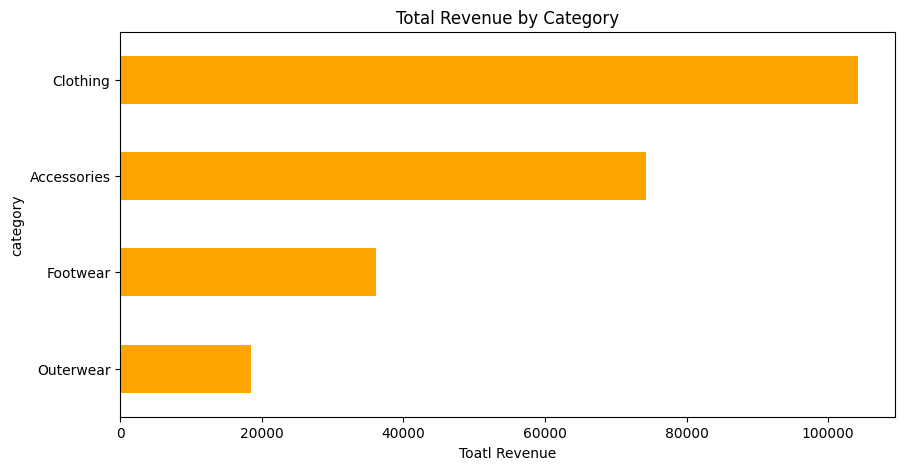

In [35]:
# Total revenue by category
revenue=df.groupby('category')['purchase_amount'].sum().sort_values()
plt.figure(figsize=(10,5))
revenue.plot(kind='barh',color='orange')
plt.title('Total Revenue by Category')
plt.xlabel('Toatl Revenue')
plt.show()

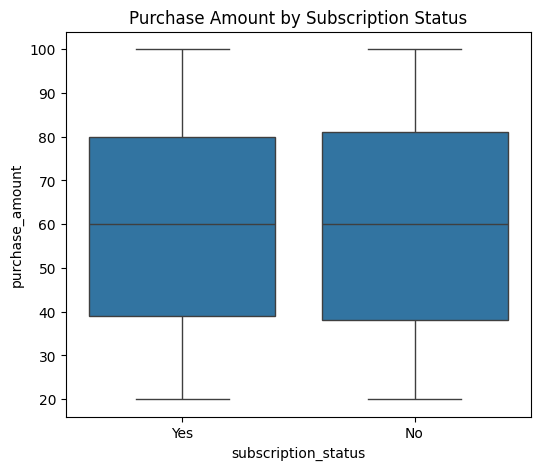

In [65]:
#Subscription Status
plt.figure(figsize=(6,5))
sns.boxplot(data=df,
            x='subscription_status',
            y='purchase_amount')

plt.title("Purchase Amount by Subscription Status")
plt.show()

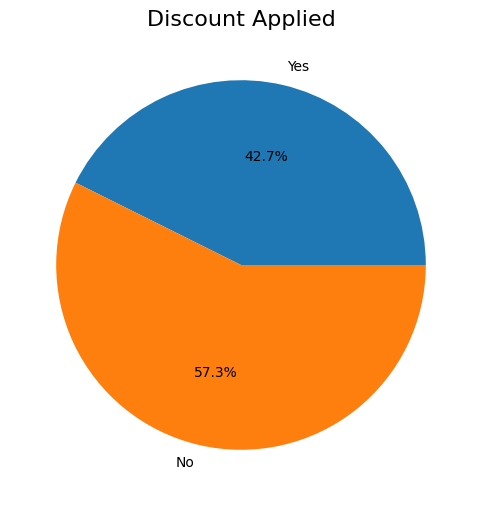

In [44]:
# Discount analysis
discount=df.groupby('discount_applied')['purchase_amount'].sum().sort_values()
plt.figure(figsize=(6,6))
plt.pie(discount,
        labels=discount.index,
        autopct='%1.1f%%')
plt.title('Discount Applied',fontsize=16)
plt.show()

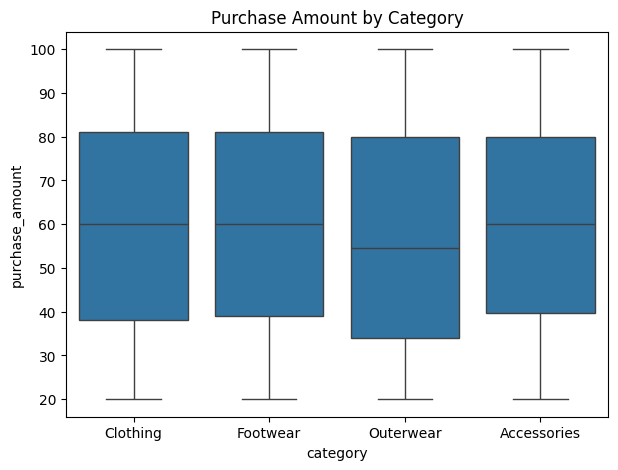

In [53]:
#Purchase by category
plt.figure(figsize=(7,5))
sns.boxplot(data=df,
            x='category',
            y='purchase_amount')
plt.title('Purchase Amount by Category')
plt.show()

Text(0, 0.5, 'Avg Rating')

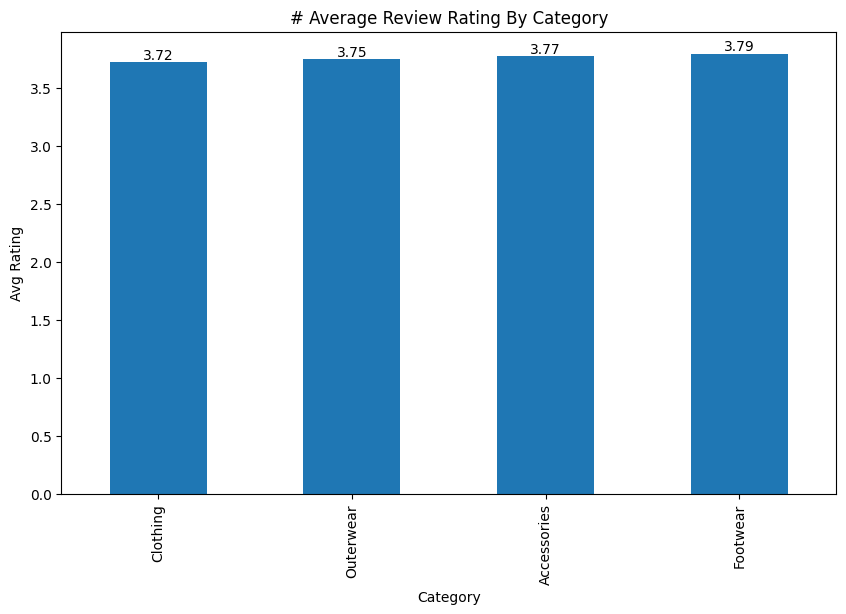

In [64]:
# Average Review Rating By Category
avg_rating=df.groupby('category')['review_rating'].mean().sort_values()
ax=avg_rating.plot(kind='bar',figsize=(10,6))

for container in ax.containers:
 ax.bar_label(container, fmt='%.2f')
plt.title('# Average Review Rating By Category')
plt.xlabel('Category')
plt.ylabel("Avg Rating")


/tmp/ipykernel_1198/1832307338.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg = df.groupby('age_group')['purchase_amount'].sum()


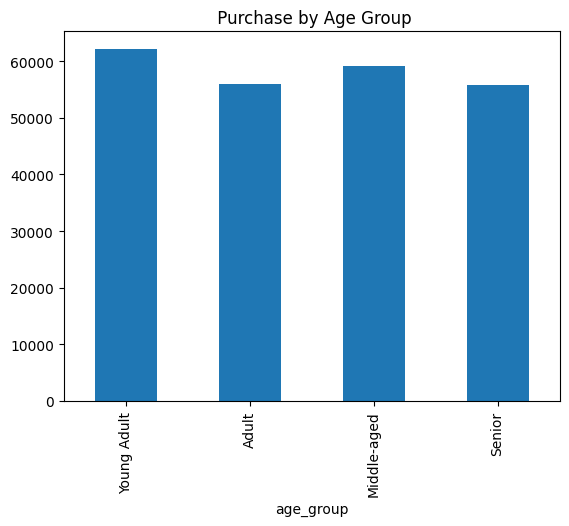

In [68]:
# purchase by age group
avg = df.groupby('age_group')['purchase_amount'].sum()

avg.plot(kind='bar')
plt.title(" Purchase by Age Group")
plt.show()